# 🌽 Phase 1 — CNN Disease Classification & Model Architecture

This notebook focuses on **Phase 1** of the MaizeGuard pipeline:
1. **Dataset Exploration (EDA):** Class distribution and inspecting leaf samples across the 4 target classes:
   - *Northern Corn Leaf Blight (NCLB)*
   - *Common Rust*
   - *Gray Leaf Spot (GLS)*
   - *Healthy*
2. **Data Augmentation:** Real-time data transformations (rotation, flips, zoom, brightness/contrast) designed for agricultural field conditions.
3. **Model Architecture:** EfficientNet-B3 transfer learning backbone with custom global pooling, dense regularization, and softmax head.
4. **Model Evaluation & Confusion Matrix:** Evaluating the trained checkpoint (`phase1_stage2_best.keras`) on real test samples.


In [1]:
# Setup & Imports
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import glob
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

from src.phase1_cnn.data_pipeline import CLASS_NAMES, IMG_SIZE, build_augmentation
from src.phase1_cnn.model import build_model

print("TensorFlow Version:", tf.__version__)
print("Target Classes:", CLASS_NAMES)
print("Native Resolution:", IMG_SIZE)


TensorFlow Version: 2.16.2
Target Classes: ['NCLB', 'Rust', 'GLS', 'Healthy']
Native Resolution: (300, 300)


### 1. Dataset Exploration & Sample Visualizations

In [2]:
# Scan PlantVillage dataset folders
data_dir = "data/raw/plantvillage/data"
classes_map = {
    "NCLB": "Blight",
    "Rust": "Common_Rust",
    "GLS": "Gray_Leaf_Spot",
    "Healthy": "Healthy"
}

dataset_stats = {}
sample_images = {}

for display_name, folder_name in classes_map.items():
    folder_path = os.path.join(data_dir, folder_name)
    images = sorted(glob.glob(os.path.join(folder_path, "*.*")))
    dataset_stats[display_name] = len(images)
    if images:
        sample_images[display_name] = images[0]

# Bar plot of dataset distribution
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71"]
bars = ax.bar(dataset_stats.keys(), dataset_stats.values(), color=colors, alpha=0.85)
ax.set_ylabel("Number of Images")
ax.set_title("PlantVillage Maize Disease Dataset Distribution", fontsize=13, pad=10)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 20, f"{yval:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


<Figure size 800x400 with 1 Axes>

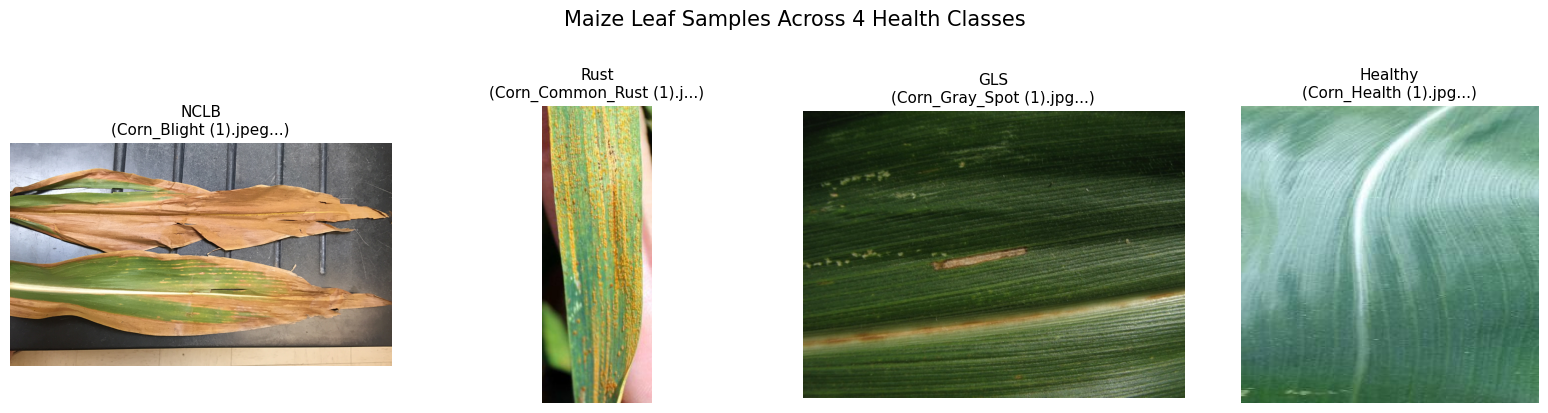

In [3]:
# Display sample leaf photographs for each class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx, (cls_name, img_path) in enumerate(sample_images.items()):
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"{cls_name}\n({os.path.basename(img_path)[:22]}...)", fontsize=11)
    axes[idx].axis("off")

plt.suptitle("Maize Leaf Samples Across 4 Health Classes", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


### 2. Data Augmentation Pipeline

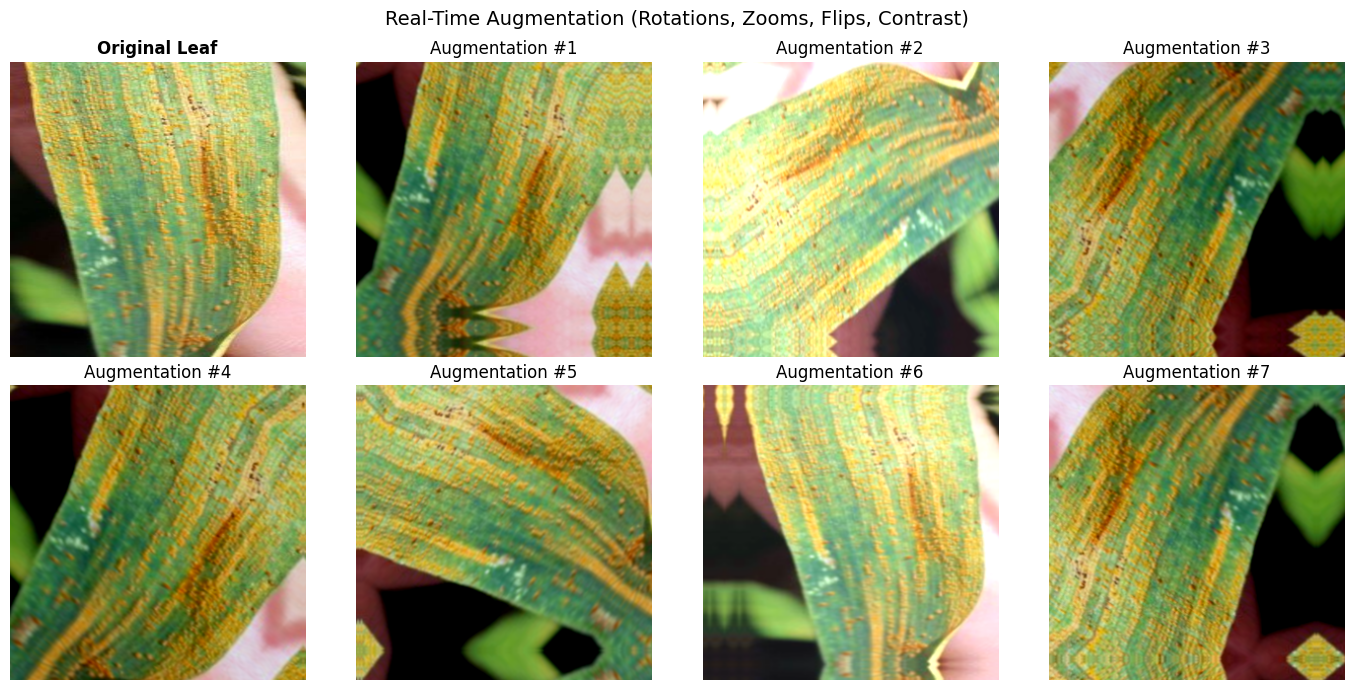

In [4]:
# Demonstrate agricultural augmentation layers
aug_pipeline = build_augmentation()

# Take one leaf image
sample_img_path = sample_images["Rust"]
raw_img = Image.open(sample_img_path).resize((300, 300))
img_tensor = tf.expand_dims(np.array(raw_img, dtype=np.float32), 0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(raw_img)
axes[0, 0].set_title("Original Leaf", fontweight="bold")
axes[0, 0].axis("off")

for i in range(1, 8):
    r, c = divmod(i, 4)
    aug_tensor = aug_pipeline(img_tensor, training=True)[0].numpy()
    aug_tensor = np.clip(aug_tensor, 0, 255).astype(np.uint8)
    axes[r, c].imshow(aug_tensor)
    axes[r, c].set_title(f"Augmentation #{i}")
    axes[r, c].axis("off")

plt.suptitle("Real-Time Augmentation (Rotations, Zooms, Flips, Contrast)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


### 3. Model Architecture & Checkpoint Inspection

In [5]:
# Load pre-trained Phase 1 model checkpoint
MODEL_PATH = "models/checkpoints/phase1_stage2_best.keras"
model = tf.keras.models.load_model(MODEL_PATH)

print(f"Loaded model from: {MODEL_PATH}")
print(f"Total layers: {len(model.layers)}")
print(f"Trainable parameters: {sum(np.prod(w.shape) for w in model.trainable_weights):,}")
print(f"Non-trainable parameters: {sum(np.prod(w.shape) for w in model.non_trainable_weights):,}")

# Show top-level head layers
print("\n--- Classification Head Layers ---")
for layer in model.layers[-7:]:
    print(f"Layer: {layer.name:<20} | Output Shape: {str(layer.output.shape):<22} | Params: {layer.count_params():,}")


Loaded model from: models/checkpoints/phase1_stage2_best.keras
Total layers: 9
Trainable parameters: 11,498,314
Non-trainable parameters: 210,665.0

--- Classification Head Layers ---
Layer: gap                  | Output Shape: (None, 1536)           | Params: 0
Layer: bn_head              | Output Shape: (None, 1536)           | Params: 6,144
Layer: dense_512            | Output Shape: (None, 512)            | Params: 786,944
Layer: dropout_1            | Output Shape: (None, 512)            | Params: 0
Layer: dense_256            | Output Shape: (None, 256)            | Params: 131,328
Layer: dropout_2            | Output Shape: (None, 256)            | Params: 0
Layer: predictions          | Output Shape: (None, 4)              | Params: 1,028


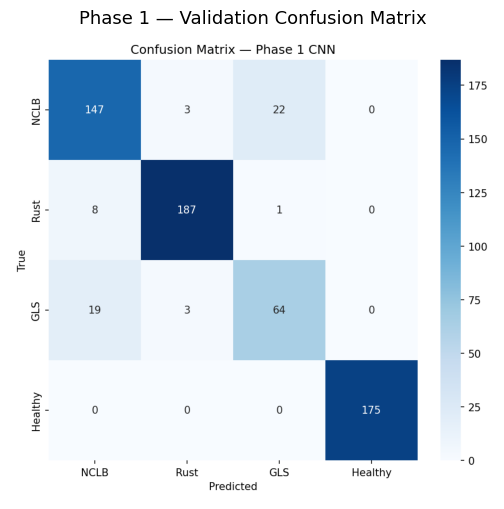

In [6]:
# Visualizing Confusion Matrix from Evaluation
cm_path = "models/exports/confusion_matrix_phase1.png"
if os.path.exists(cm_path):
    cm_img = Image.open(cm_path)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm_img)
    plt.axis("off")
    plt.title("Phase 1 — Validation Confusion Matrix", fontsize=13, pad=10)
    plt.show()
else:
    print("Confusion matrix image not found at", cm_path)
